# Exploring Mentions 

## Setup and Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go

In [42]:
mentions = pd.read_csv("data/mentions.csv")
mentions.head().T

/var/folders/p9/9vqlyg213v3b9h9zrksgz6z00000gn/T/ipykernel_18394/1594462463.py:1: DtypeWarning:

Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.



,0,1,2,3,4
mention_id,ALB-CH-1851-2071,ALB-VR-1715-4362,ALB-VR-1715-4362.1,ALB-VR-1715-4362.2,ALB-VR-1715-4362.3
source,ALB_CH_1851,ALB_VR_1715,ALB_VR_1715,ALB_VR_1715,ALB_VR_1715
source_year,1851,1868,1868,1868,1868
county,ALB,ALB,ALB,ALB,ALB
original_data,"{""line"": ""2071"", ""race"": ""B"", ""gender"": ""F"", ""...","{""line"": ""4362"", ""note"": """", ""race"": ""B"", ""typ...","{""line"": ""4362"", ""note"": """", ""race"": ""B"", ""typ...","{""line"": ""4362"", ""note"": """", ""race"": ""B"", ""typ...","{""line"": ""4362"", ""note"": """", ""race"": ""B"", ""typ..."
confidence,0.8,0.84,0.85,0.85,0.85
full_name,Martha,Nicey Ann Coles,Coles,Coles,Coles
first_name,Martha,Nicey,Coles,Coles,Coles
middle_name,NaN,Ann,NaN,NaN,NaN
last_name,NaN,Coles,Coles,Coles,Coles


In [43]:
mentions.shape

(114070, 31)

## Look at Non Nulls

In [44]:
na_counts=mentions.notna().sum().to_frame().reset_index()
na_counts.columns=['column','non_null_count']
na_counts['dtype'] = mentions.dtypes.values
na_counts.head()

,column,non_null_count,dtype
0,mention_id,114070,object
1,source,114070,object
2,source_year,114070,int64
3,county,114070,object
4,original_data,114070,object


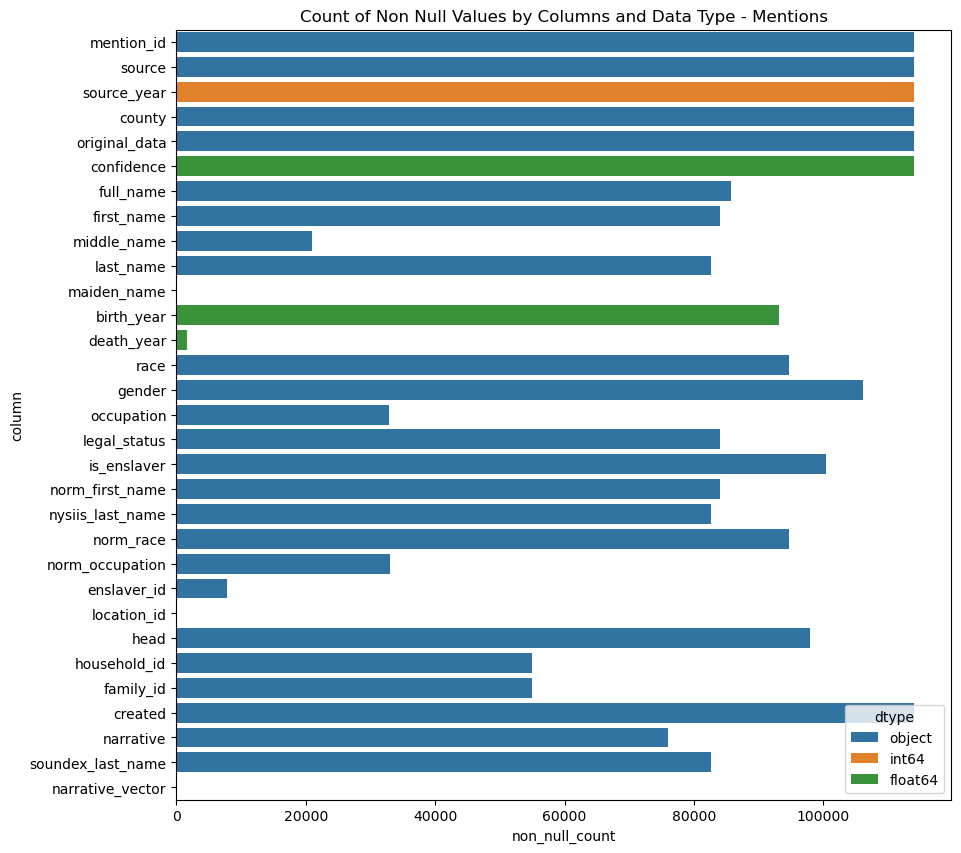

In [45]:
plt.figure(figsize=(10, 10))
sns.barplot(x='non_null_count', y = 'column', data=na_counts, hue='dtype')
plt.title('Count of Non Null Values by Columns and Data Type - Mentions')
plt.show()

## Look at occupation

In [46]:
mentions['occupation'].value_counts()

occupation
At Home                  6012
Keeping House            5617
Farm Laborer             2609
Farmer                   2560
At home                  1522
                         ... 
Guano Merchant              1
Dont in Foundry             1
EYpress Hand                1
Embroiderist                1
Retired Fram Business       1
Name: count, Length: 1157, dtype: int64

`norm_occupation` is a normalized version of occupation that puts job into categories. Lets see what categories there are and how often they occur in the mentions dataset.

In [47]:
mentions['norm_occupation'].value_counts()

norm_occupation
DOMESTIC          17929
AGRICULTURE        7978
EDUCATION          2101
LABORER            1589
WOODWORK            695
CONSTRUCTION        364
TRANSPORTATION      330
COMMERCE            305
LEATHER             257
OFFICE              214
FOOD                202
METAL               193
PROFESSION          182
HOSPITALITY         148
TEXTILE             130
CRAFTSMAN           106
RELIGION             83
GOVERNMENT           64
MANUFACTURING        61
EXTRACTION           42
Name: count, dtype: int64

In [48]:
domestic_df = mentions.query('norm_occupation == "DOMESTIC"')['occupation'].value_counts().to_frame()
domestic_df.reset_index(inplace=True)
domestic_df.columns = ['occupation','count']
domestic_df.head()

,occupation,count
0,At Home,6012
1,Keeping House,5617
2,At home,1522
3,Keeping house,775
4,Servant,669


In [49]:
fig = go.Figure(data=[go.Table(
    header=dict(values=domestic_df.columns.to_list(),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[domestic_df['occupation'].to_list(), domestic_df['count'].to_list() ],
               fill_color='lavender',
               align='left'))
])
fig.update_layout(title='Occupations with Normalized Occupation DOMESTIC')

fig.show()

Domestic category contains many jobs that involve housework, cooking, etc. 

## Look the Last Name

In [50]:
mentions['last_name'].value_counts()

last_name
Brown       2118
Johnson     1812
Wood        1344
Jones       1228
Smith       1037
            ... 
GILMER         1
Chockley       1
BENNET         1
Sacree         1
Townly         1
Name: count, Length: 6161, dtype: int64

Brown is the most popular last name.

nysiis encodes last names. Let's see what the different nysiis last names are.

In [51]:
mentions['nysiis_last_name'].value_counts()

nysiis_last_name
BRAN         2161
JANSAN       1847
WAD          1620
JANA         1550
SNAT         1059
             ... 
TANASJANA       1
JANAL           1
EGAS            1
MARNDAN         1
DAVASAN         1
Name: count, Length: 3695, dtype: int64

BRAN is the most common `nyisiis_last_name`. What all last names are encoded as BRAN?

In [52]:
brown_df = mentions.query('nysiis_last_name == "BRAN"')['last_name'].value_counts().to_frame()
brown_df.reset_index(inplace=True)
brown_df.columns = ['last_name','count']
brown_df    

,last_name,count
0,Brown,2118
1,Braun,7
2,Bruns,6
3,Brim,6
4,Brown?,5
5,Browen,5
6,Brann,3
7,Brian,3
8,Brien,3
9,BROWN,2


In [53]:

fig = go.Figure(data=[go.Table(
    header=dict(values=brown_df.columns.to_list(),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[brown_df['last_name'].to_list(), brown_df['count'].to_list() ],
               fill_color='lavender',
               align='left'))
])
fig.update_layout(title='Last Names with Nysiis Code BRAN')

fig.show()

## Look at Race

In [54]:
mentions['race'].value_counts()

race
B    56312
W    28150
M    10241
I       39
Name: count, dtype: int64

In [55]:
mentions['norm_race'].value_counts()

norm_race
B    66592
W    28150
Name: count, dtype: int64

`norm_race` only has B and W, while race `race` includes I and M.

In [56]:
race_counts=mentions['race'].value_counts().reset_index()
race_counts.columns=['race', 'count']
race_counts

,race,count
0,B,56312
1,W,28150
2,M,10241
3,I,39


In [57]:
px.bar(race_counts, x='race', y = 'count', title='Race Counts',color='race',text_auto=True)

In [58]:
norm_race_counts=mentions['norm_race'].value_counts().reset_index()
norm_race_counts.columns=['norm_race', 'count']
norm_race_counts['percentage'] = norm_race_counts['count']/norm_race_counts['count'].sum()
norm_race_counts


,norm_race,count,percentage
0,B,66592,0.702877
1,W,28150,0.297123


In [59]:
px.bar(norm_race_counts, x='norm_race', y = 'count', title='Race Counts',color='norm_race',text_auto=True)

For both `norm_race` amd `race`, the most common race is Black.

## Look at Gender

In [60]:
gender_counts=mentions['gender'].value_counts().reset_index()
gender_counts.columns=['gender', 'count']
gender_counts

,gender,count
0,F,53564
1,M,52592


In [61]:
px.bar(gender_counts, x='gender', y = 'count', title='Gender Counts',color='gender',color_discrete_map={'F':'pink','M':'blue'},text_auto=True)    


There is almost a balance of males are females in the dataset.

## Look at Sources

In [62]:
mentions['source'].value_counts().to_frame()


,count
source,
ALB_CN_1880,32415
ALB_VR_1715,23423
ALB_CN_1870,22587
ALB_SS-1860,15639
ALB_SS-1850,14069
ALB_CH_1851,3133
ALB_FindAGrave,1611
ALB_FBR,1193


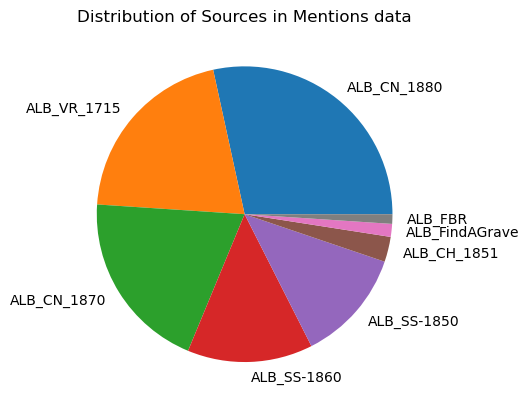

In [63]:
plt.pie(mentions['source'].value_counts(), labels=mentions['source'].value_counts().index)
plt.title("Distribution of Sources in Mentions data")
plt.show()

The two census data and the vital records are the most common in the mentions data set.